In [7]:
from cogent3.maths.matrix_exponential_integration import expected_number_subs
import matplotlib.pyplot as plt
import paths
import pandas as pd

import pickle

import re

In [8]:
#function to parse the alignment lenght

def parse_alignment_length(s: str, fmt: str = "{:.6e}") -> str:
    """
    Parse strings like "alignment length: X" and return X formatted in scientific notation.

    Parameters
    - s: input string containing a token like "alignment length: 12345"
    - fmt: a format string compatible with float.format, default "{:.6e}" (6 decimals in exp notation)

    Returns
    - str: the parsed number formatted according to `fmt` (scientific notation by default)

    Raises ValueError if the token is not found.
    """
    m = re.search(r'alignment\s*length\s*:\s*([0-9]+(?:\.[0-9]+)?)', s, re.I)
    if not m:
        raise ValueError(f"Can't parse alignment length from: {s!r}")
    token = m.group(1)
    # normalize to float for consistent formatting
    value = float(token)
    return fmt.format(value)

## Intergenic Ancestral Repeats (IGAR)

In [9]:
region = "intergenicAR/chrm22/"
folder_in = paths.DATA_HUMCHIMPGOR116 + region
file_in = folder_in + "sm_output/singlent_lh.pickle"
with open(file_in, mode = "rb") as infile: 
    result_IGAR=pickle.load(infile)

file_in = folder_in + "singlent_filtered_alnstat.txt"
with open(file_in, "r") as f:
    content = f.read().strip()
print("alignment lenght ", parse_alignment_length(content))

IGAR_motif_probs = result_IGAR.lf.get_param_value("mprobs")
humanQ_IGAR = result_IGAR.lf.get_rate_matrix_for_edge("Human", calibrated=False)
humanENS_IGAR = expected_number_subs(IGAR_motif_probs, humanQ_IGAR, t=1.0)

print("Human ENS IGAR: ")
print(humanENS_IGAR)

result_IGAR.lf

alignment lenght  1.744600e+04
Human ENS IGAR: 
0.2267744050734619


GN
log-likelihood = -64584.4348
number of free parameters = 36
======================================================================
edge          parent    length     A>C     A>G     A>T     C>A     C>G
----------------------------------------------------------------------
Chimpanzee    root        0.33    1.13    1.04    1.30    1.20    0.75
Gorilla       root          NA      NA      NA      NA      NA      NA
Human         root        0.23    0.95    0.90    1.14    0.65    0.71
----------------------------------------------------------------------

continued: 
============================================
 C>T     G>A     G>C     G>T     T>A     T>C
--------------------------------------------
1.04    0.87    0.68    0.93    1.19    1.11
  NA      NA      NA      NA      NA      NA
0.85    0.77    0.55    0.80    1.08    0.90
--------------------------------------------

============================
   A       C       G       T
----------------------------
0.24    0.24    0.25    0.26
----------------------------
=========================
motif    motif2    dpsubs
-------------------------
T        T           0.57
T        C           0.14
T        A           0.15
T        G           0.15
C        T           0.16
C        C           0.58
C        A           0.13
C        G           0.13
A        T           0.16
A        C           0.14
A        A           0.55
A        G           0.15
G        T           0.13
G        C           0.14
G        A           0.13
G        G           0.59
-------------------------

## CDS

In [10]:
region = "cds/chrm22/"
folder_in = paths.DATA_HUMCHIMPGOR116 + region
file_in = folder_in + "sm_output/singlent_lh.pickle"
with open(file_in, mode = "rb") as infile: 
    result_cds=pickle.load(infile)

file_in = folder_in + "singlent_filtered_alnstat.txt"
with open(file_in, "r") as f:
    content = f.read().strip()
print("alignment lenght ", parse_alignment_length(content))

cds_motif_probs = result_cds.lf.get_param_value("mprobs")
humanQ_cds = result_cds.lf.get_rate_matrix_for_edge("Human", calibrated=False)
humanENS_cds = expected_number_subs(cds_motif_probs, humanQ_cds, t=1.0)
#This is the ENS of cdss if selection was the same as on IGAR. Instead of using the cds Q matrix humanQ_cds, I use the IGAR Q humanQ_IGAR
humanENS_cds_IGARQ = expected_number_subs(cds_motif_probs, humanQ_IGAR, t=1.0)

print("Human ENS cds: ")
print(humanENS_cds)
print("Human ENS cds with IGAR Q: ")
print(humanENS_cds_IGARQ)

result_cds.lf

alignment lenght  5.469040e+05
Human ENS cds: 
0.004424028666712195
Human ENS cds with IGAR Q: 
0.22147418066471003


GN
log-likelihood = -824918.8114
number of free parameters = 36
======================================================================
edge          parent    length     A>C     A>G     A>T     C>A     C>G
----------------------------------------------------------------------
Chimpanzee    root        0.01    0.98    2.03    0.78    0.85    1.20
Gorilla       root          NA      NA      NA      NA      NA      NA
Human         root        0.00    1.16    4.03    0.59    1.41    1.70
----------------------------------------------------------------------

continued: 
============================================
 C>T     G>A     G>C     G>T     T>A     T>C
--------------------------------------------
3.10    2.70    1.38    0.90    0.64    2.30
  NA      NA      NA      NA      NA      NA
7.47    6.35    1.42    1.14    0.81    3.52
--------------------------------------------

============================
   A       C       G       T
----------------------------
0.23    0.29    0.29    0.19
----------------------------
=========================
motif    motif2    dpsubs
-------------------------
T        T           0.99
T        C           0.00
T        A           0.00
T        G           0.00
C        T           0.01
C        C           0.99
C        A           0.00
C        G           0.00
A        T           0.00
A        C           0.00
A        A           0.99
A        G           0.00
G        T           0.00
G        C           0.00
G        A           0.01
G        G           0.99
-------------------------

Text(0, 0.5, 'Constraint')

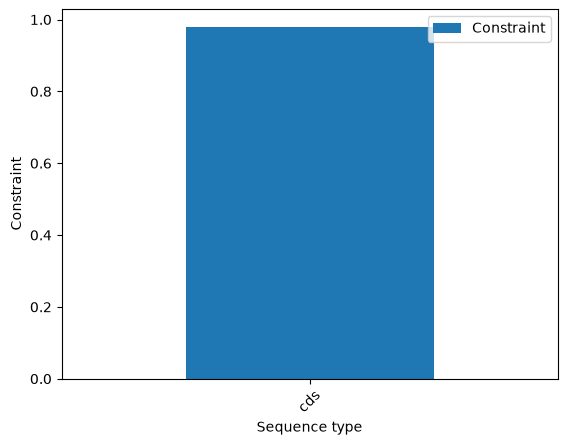

In [11]:
Constraint_data = pd.DataFrame([
    ['cds', (humanENS_cds_IGARQ - humanENS_cds)/humanENS_cds_IGARQ]
    ],
    columns = ['Sequence type', 'Constraint'])


Constraint_data.plot(
    x='Sequence type',
    kind = 'bar',
    rot=45)
plt.ylabel('Constraint')

In [12]:
#Constraint_data.to_csv("Output_data/Constraint_perregion.csv", index=False)
Constraint_data

,Sequence type,Constraint
0,cds,0.980025
